## Дисклеймер!!!!!

Поскольку я терпеть ненавижу отвратно структурированный код, я большую часть инжиринга признаков вынес в отдельный файл. Направление действий будет видно как и указано в задании, но сразу для всего. Я не писал всё одним батчем, тут положена куча коммитов, просто для сохранения ясности я решил не сваливать всё в одну нечитабельную кучу. 

По поводу баллов - претендую на баллы за каждый из указанныз в ДЗ пунктов

## Грузим данные

Из основных фич которые я выделил за это время:

1) Количество добавлений в корзину/поисков/просмотров
2) "Вероятность" добавления в корзину при наличии клика по товару
3) Статистики по количествуй действий за каждую сессию (40 минут)
4) Последние 3/2/1 действия(е)
5) TFIDF + SVD по тексту поиска
6) Флаги на запросы по самым популярным продуктам питания
7) Количество уникальных запросов
8) Статистики по длине запроса в словах/символях (медианная, максимальная, средняя)
9) Последний запрос, его длина в символах и словах
10) Средняя/максимальная/минимальная цена просмотренного товара
11) Доля товаров купленных по скидке
12) Среднее значение скидки
13) Доля наиболее частой категории товаров

+ все признаки которые были в преложенном решении

Скор - 0.81949

### UPD
Добавил в `embedding_features` колонку-список эмбеддингов поиска TFIDF+SVD, результат только ухудшился (примерно на 0.002)

### UPD 2
Добавил ещё кучу признаков:

14)  Динамика активности
- Количество действий за последние 7/30 дней и за предыдущие периоды (предыдущие 7 и 30 дней)
- Отдельно считаются: клики, добавления в корзину, заказы, поиски, уникальные товары
- Разности между окнами (например: actions_last_7d - actions_prev_7d)
- Отношения между окнами (например: (actions_last_7d + 1) / (actions_prev_7d + 1))
- Аналогичные признаки для кликов, корзины, заказов и поисков

15)  Конверсия поиска в действия
- Количество переходов:
  - search → click в течение 5 / 30 / 60 минут
  - search → to_cart в течение 5 / 30 / 60 минут
- Среднее время от поиска до клика
- Среднее время от поиска до добавления в корзину
- Нормированные коэффициенты:
  - search_to_click_rate
  - search_to_cart_rate

16)  Признаки по виджетам
- Общее количество действий через виджеты
- Количество уникальных виджетов
- Самый частый виджет (favorite_widget)
- Последний использованный виджет
- Доля действий из самого частого виджета (favorite_widget_share)
- Энтропия распределения по виджетам
- Доли действий в топ-K наиболее популярных виджетах

17)  Повторяемость и лояльность
- Количество уникальных товаров, категорий, брендов
- Количество повторных взаимодействий (один и тот же объект более одного раза)
- Доля повторных товаров 
- Доля повторных категорий
- Доля повторных брендов
- Доля наиболее популярного товара/категории/бренда
- Повторяемость отдельно для действий:
  - click
  - to_cart
  - order

Скор - 0.81987

In [1]:
from data_preparation import OzonDataFormer
from datetime import date

In [2]:
former = OzonDataFormer()

In [3]:
former.fit_text_vectorizer(feature_end_date=date(2024, 5, 31))

In [4]:
data_params = {
    'include_actions': True,
    'include_search': True,
    'include_price': True,
    # UPD
    'group_embedding': False,
    # UPD 2
    'include_trend': True,
    'include_action_conversion': True,
    'include_repeat_loyalty': True,
    'include_widget': False,
}

In [5]:
train_df = former.construct_dataset(
    feature_end_date=date(2024, 5, 31),
    target_start_date=date(2024, 6, 1),
    target_end_date=date(2024, 6, 30),
    **data_params
)

In [6]:
val_df = former.construct_dataset(
    feature_end_date=date(2024, 6, 30),
    target_start_date=date(2024, 7, 1),
    target_end_date=date(2024, 7, 31),
    **data_params
)

In [7]:
X_train = train_df.drop(columns=['user_id', 'target'])
y_train = train_df['target']

In [8]:
X_val = val_df.drop(columns=['user_id', 'target'])
y_val = val_df['target']

In [9]:
from utils2 import AutoFeatureStandardizer

In [10]:
standardizer = AutoFeatureStandardizer()

In [11]:
X_train = standardizer.fit_transform(X_train)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1501: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1501: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1501: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

In [12]:
X_val = standardizer.transform(X_val)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1501: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1501: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1501: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

## Проверка адекватности разделения на тренировку и валидацию

In [13]:
import numpy as np

In [14]:
cat_features = list(X_train.select_dtypes('category').columns)

In [15]:
embedding_features = ['search_emb'] if 'search_emb' in X_train.columns else None

In [16]:
from catboost.utils import get_gpu_device_count

if get_gpu_device_count() > 0:
    task_type = 'GPU'
else:
    task_type = 'CPU'

params = {
    'iterations': 100,
    'depth': 7,
    'random_state': 1,
    'eval_metric': 'AUC',
    'loss_function': 'Logloss',
    'auto_class_weights': 'Balanced',
    'task_type': task_type,
    'cat_features': cat_features,
    'embedding_features': embedding_features
}

# search_tfidfsvd

In [17]:
from validation_check import get_train_val_difference

diff_score, _, _ = get_train_val_difference(X_train, y_train, X_val, y_val, params)

Learning rate set to 0.094354


Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7893312	best: 0.7893312 (0)	total: 77.6ms	remaining: 7.69s
10:	test: 0.8092136	best: 0.8092136 (10)	total: 641ms	remaining: 5.18s
20:	test: 0.8115609	best: 0.8115609 (20)	total: 1.18s	remaining: 4.44s
30:	test: 0.8125301	best: 0.8125301 (30)	total: 1.71s	remaining: 3.81s
40:	test: 0.8130487	best: 0.8130487 (40)	total: 2.26s	remaining: 3.25s
50:	test: 0.8135808	best: 0.8135808 (50)	total: 2.8s	remaining: 2.69s
60:	test: 0.8139582	best: 0.8139582 (60)	total: 3.34s	remaining: 2.14s
70:	test: 0.8142491	best: 0.8142491 (70)	total: 3.91s	remaining: 1.6s
80:	test: 0.8147027	best: 0.8147027 (80)	total: 4.4s	remaining: 1.03s
90:	test: 0.8149344	best: 0.8149344 (90)	total: 4.88s	remaining: 483ms
99:	test: 0.8150712	best: 0.8150712 (99)	total: 5.32s	remaining: 0us
bestTest = 0.8150712252
bestIteration = 99


In [18]:
diff_score

0.7110694028195585

Скор получился примерно 0.78. Ну выглядит вроде адекватно учитывая что в данных очевидно есть временная зависимость

### UPD
Периодически при добавлении новых признаков скор менялся от 0.7 до 0.85. Всё ещё норм, опять же дрифт временных данных тут играет свою роль.

## Обучение модели

In [19]:
from catboost import CatBoostClassifier, Pool

In [20]:
cat_features

['last_2_action', 'last_3_action', 'last_3_actions_str', 'last_action']

In [21]:
train_pool = Pool(
    X_train,
    label=y_train,
    cat_features=params.get('cat_features'),
    embedding_features=params.get('embedding_features')
)

val_pool = Pool(
    X_val,
    label=y_val,
    cat_features=params.get('cat_features'),
    embedding_features=params.get('embedding_features')
)

In [22]:
params['iterations'] = 5000

model = CatBoostClassifier(**params)

In [23]:
(set(X_train.columns) | set(X_val.columns)) ^ (set(X_train.columns) & set(X_val.columns))

set()

In [24]:
model_name = "models/less_weird3.bin"

try:
    model.load_model(model_name)
except Exception:
    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True,
        verbose=10,
        early_stopping_rounds=50,
    )
    model.save_model(model_name)

Learning rate set to 0.199979
0:	learn: 0.6355370	test: 0.6322847	best: 0.6322847 (0)	total: 347ms	remaining: 5m 46s
10:	learn: 0.5383370	test: 0.5308781	best: 0.5308781 (10)	total: 3.23s	remaining: 4m 50s
20:	learn: 0.5345210	test: 0.5278694	best: 0.5278694 (20)	total: 6.06s	remaining: 4m 42s
30:	learn: 0.5333485	test: 0.5271218	best: 0.5271218 (30)	total: 8.91s	remaining: 4m 38s
40:	learn: 0.5326682	test: 0.5268283	best: 0.5268283 (40)	total: 11.7s	remaining: 4m 34s
50:	learn: 0.5320314	test: 0.5266444	best: 0.5266444 (50)	total: 14.6s	remaining: 4m 31s
60:	learn: 0.5315215	test: 0.5264763	best: 0.5264763 (60)	total: 17.4s	remaining: 4m 27s
70:	learn: 0.5310910	test: 0.5262680	best: 0.5262547 (69)	total: 20.2s	remaining: 4m 24s
80:	learn: 0.5307048	test: 0.5260966	best: 0.5260459 (79)	total: 23.1s	remaining: 4m 22s
90:	learn: 0.5303296	test: 0.5258946	best: 0.5258946 (90)	total: 26s	remaining: 4m 19s
100:	learn: 0.5300116	test: 0.5257438	best: 0.5257438 (100)	total: 28.7s	remaining: 

In [25]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

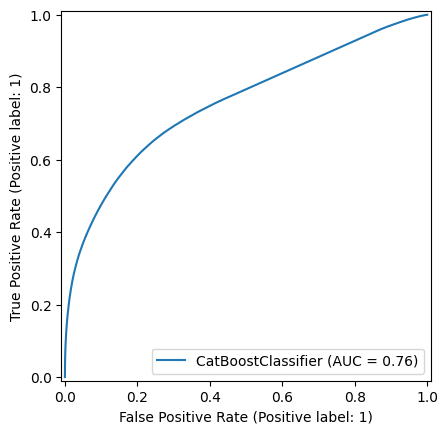

In [26]:
RocCurveDisplay.from_estimator(model, X_val, y_val)

## Интерпретация модели

In [27]:
from utils2 import AutoFeatureStandardizer, BinaryClassifierInterpreter
from cluster_compare import NotebookBinaryClusterInterpreter
from bokeh.io import output_notebook

In [28]:
import panel as pn
pn.extension()

In [29]:
output_notebook()

tool = NotebookBinaryClusterInterpreter(
    X=X_train.loc[::30],
    y=y_train.loc[::30],
)
tool.show()

Loading BokehJS ...

/home/i3alumba/Projects/AI/aim_ml/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


BokehModel(combine_events=True, render_bundle={'docs_json': {'04fe2a10-f8ed-47c2-9287-a3be9978c198': {'version…

А выглядит интересно, чётко видны 2 кластера, надо посмотреть чё там такое.

### UPD
Я добавил соотношение меток классов к кластерам, получается интересная картина. В левом кластере оба класса представлены $\pm$ одинаково, а во втором соотношение примерно 50/50. Мб имеет смысл использовать результаты кластеризации как признаки для модели, но надо хорошо подумать над алгоритмом кластеризации

### UPD 2
Я добавил SHAP, к сожалению никаких особых откровений. По большому счёту - разделение пользователей по активности.

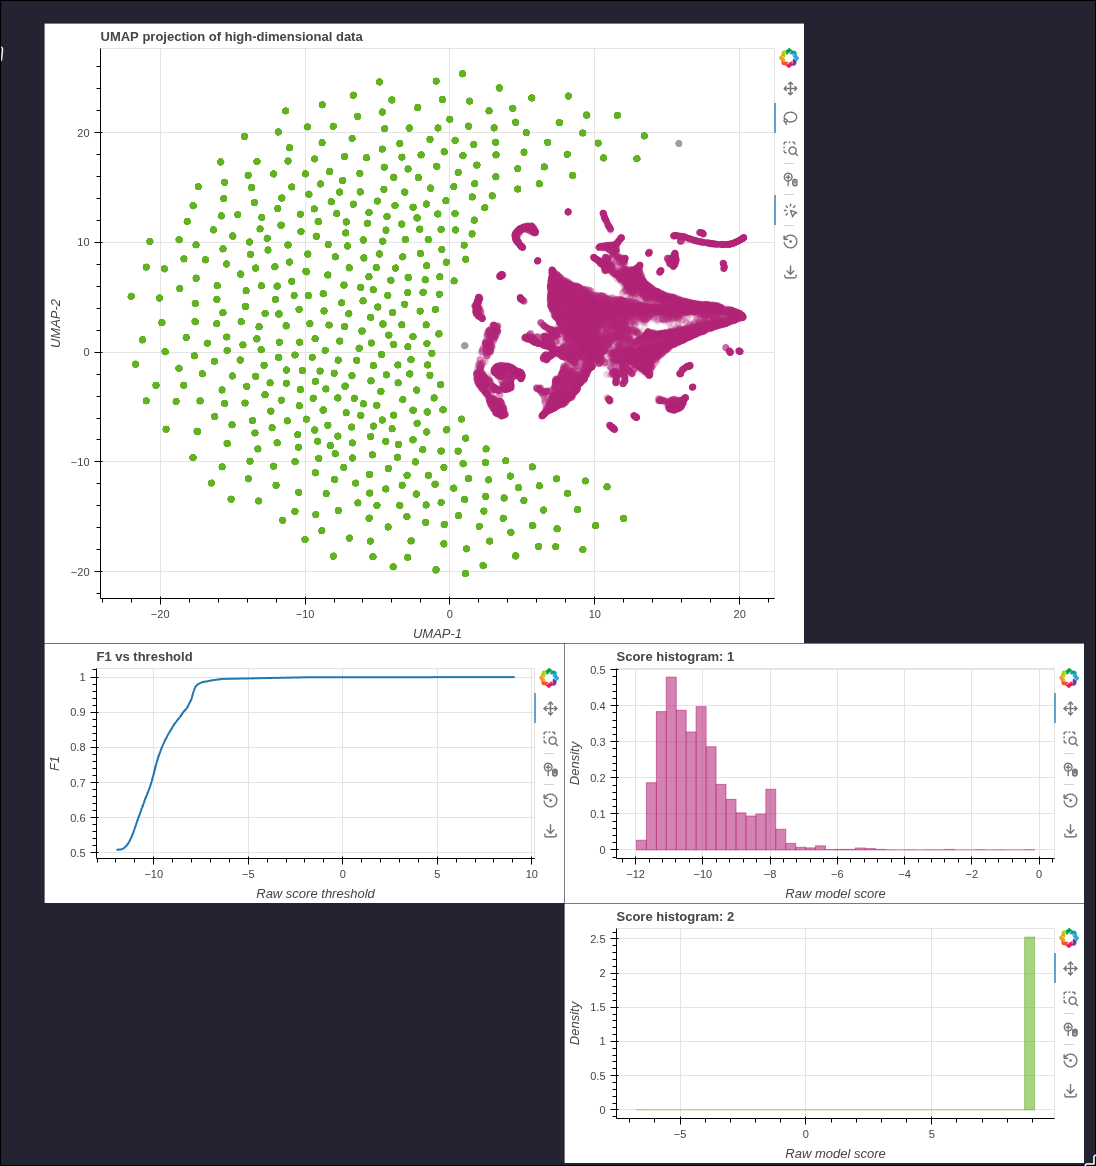

In [30]:
interpreter = BinaryClassifierInterpreter(
    train=(X_train[::30], y_train[::30]),
    val=(X_val[::10], y_val[::10]),
    model=model
)

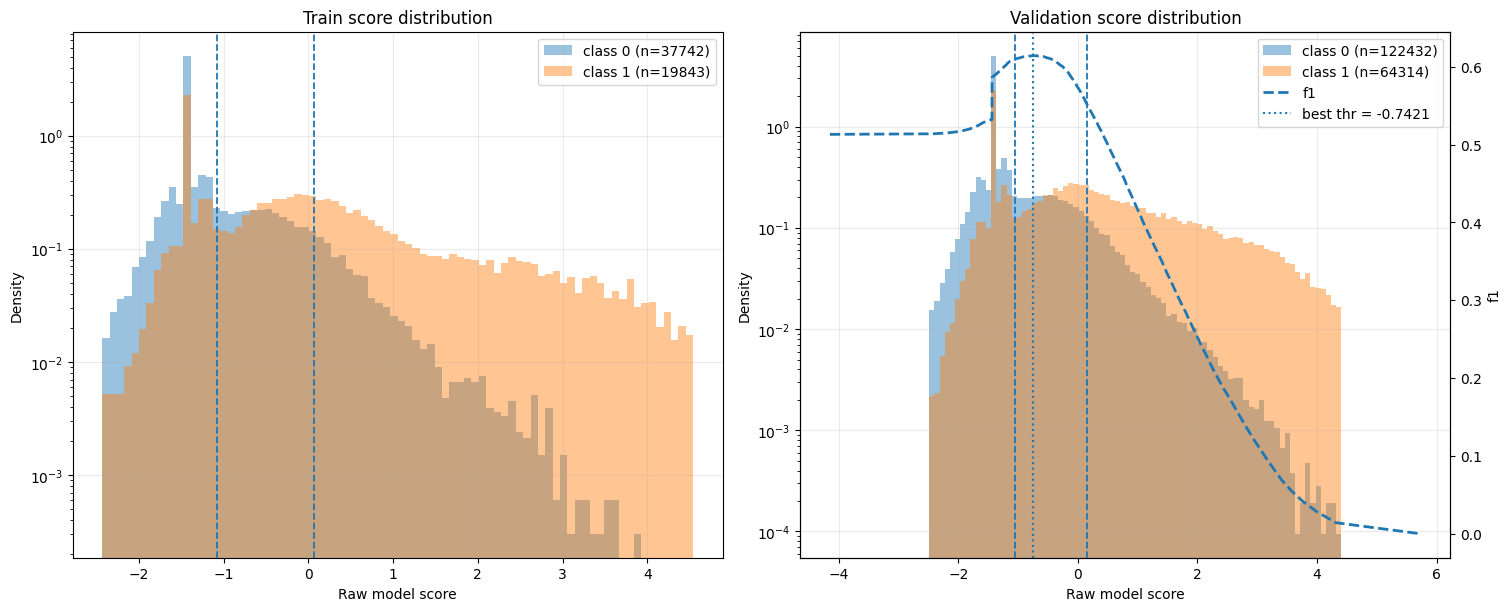

In [31]:
interpreter.plot_score_histograms_with_val_metric(val_metric_name="f1", use_log_density_y=True);

In [32]:
interpreter.plot_float_feature_histograms()

In [33]:
interpreter.plot_score_feature_contours()

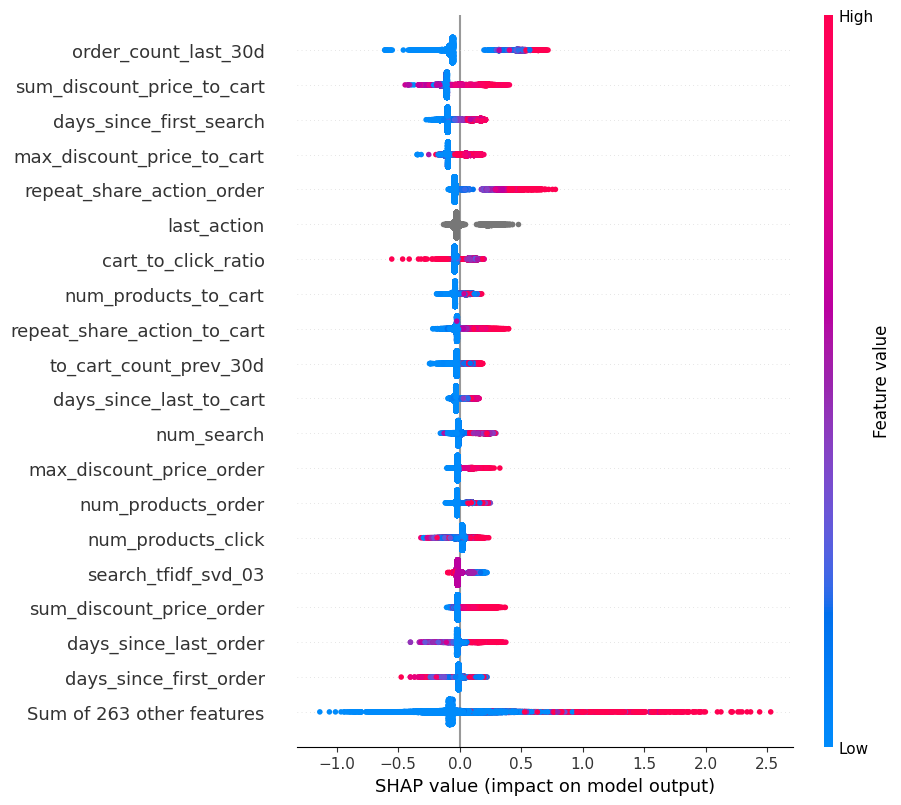

In [34]:
interpreter.plot_shap_beeswarm(sample_frac=0.1);

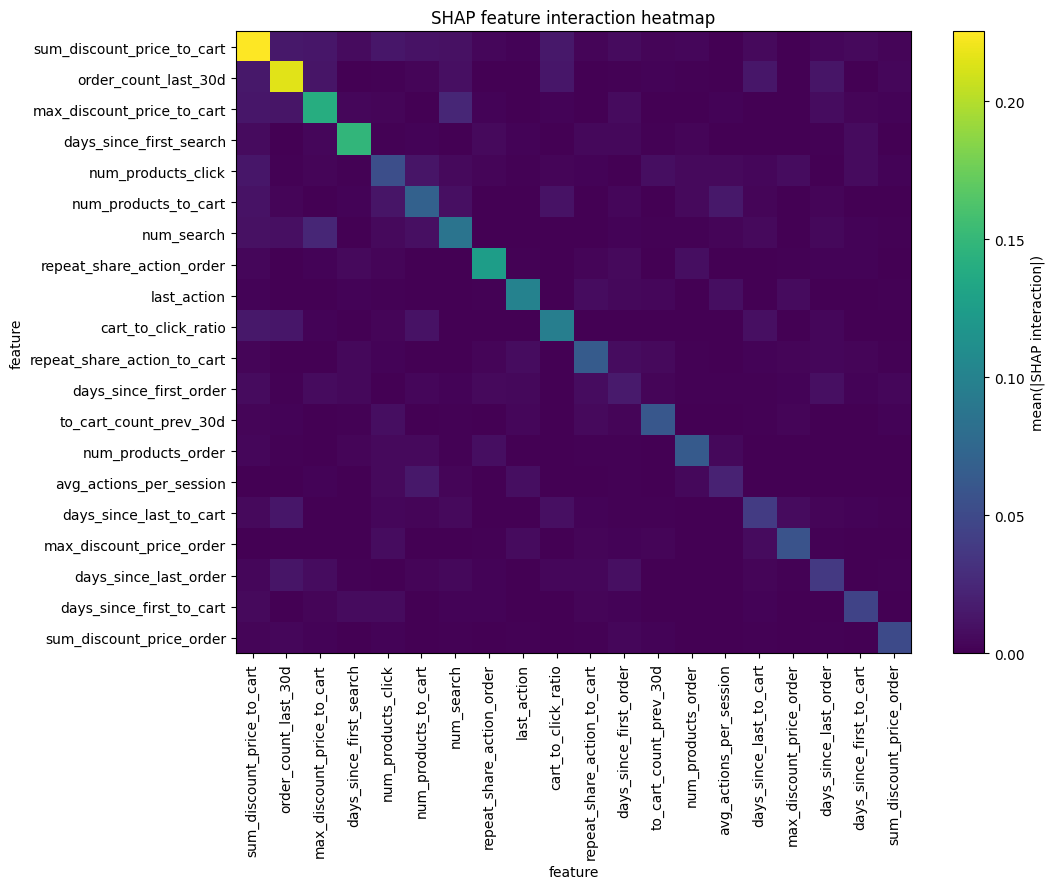

In [35]:
interpreter.plot_shap_interaction_heatmap();

Пока не видно признаков с сильным взаимодействием, посмотрим когда появятся новые

## Тюнинг параметров


Скор - 0.82092

In [47]:
do_tune = True

In [48]:
import optuna
from sklearn.metrics import roc_auc_score

In [57]:
def objective(trial: optuna.Trial):
    eta = trial.suggest_float("eta", 1e-3, 1.0, log=True)
    depth = trial.suggest_int("depth", 5, 10)
    
    params['eta'] = eta
    params['depth'] = depth
        
    model = CatBoostClassifier(**params)

    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True,
        verbose=False,
        early_stopping_rounds=50,
    )

    preds = model.predict_proba(X_val)[:, 1]
    
    score = roc_auc_score(y_val, preds)
    return score

In [60]:
if do_tune:
    study = optuna.create_study(direction='maximize')
    params['iterations'] = 500
    study.optimize(objective, n_trials=100)
    
    from optuna.visualization import plot_contour
    from plotly.io import show
    
    fig = plot_contour(study)

    show(fig)
    
    best_params = study.best_params
else:
    best_params = {'eta': 0.055848570897405615, 'depth': 8}

[I 2026-04-15 02:31:21,688] A new study created in memory with name: no-name-f6e2b34f-dcbb-421f-a2cc-af87637fa397
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-15 02:32:00,398] Trial 0 finished with value: 0.755337810538548 and parameters: {'eta': 0.009688265064928423, 'depth': 8}. Best is trial 0 with value: 0.755337810538548.
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-15 02:32:14,793] Trial 1 finished with value: 0.7566722482112516 and parameters: {'eta': 0.1908762745078631, 'depth': 9}. Best is trial 1 with value: 0.7566722482112516.
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-15 02:32:53,520] Trial 2 finished with value: 0.7549918900015363 and parameters: {'eta': 0.007716952344471377, 'depth': 8}. Best is trial 1 with value: 0.7566722482112516.
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-15 02:33:56,170] Trial 3 finished with value: 0.75

In [61]:
best_params

{'eta': 0.09094570381895212, 'depth': 7}

Лучшие параметры - {'eta': 0.09094570381895212, 'depth': 7}

In [62]:
params.update(best_params)
params['iterations'] = 5000

## Финальное предсказание

In [63]:
model = CatBoostClassifier(**params)

model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True,
        verbose=10,
        early_stopping_rounds=50,
    )
model.save_model(model_name)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7451144	best: 0.7451144 (0)	total: 59.4ms	remaining: 4m 56s
10:	test: 0.7523097	best: 0.7523097 (10)	total: 685ms	remaining: 5m 10s
20:	test: 0.7536369	best: 0.7536369 (20)	total: 1.32s	remaining: 5m 12s
30:	test: 0.7542537	best: 0.7542537 (30)	total: 2s	remaining: 5m 20s
40:	test: 0.7546087	best: 0.7546087 (40)	total: 2.63s	remaining: 5m 17s
50:	test: 0.7548820	best: 0.7548820 (50)	total: 3.25s	remaining: 5m 15s
60:	test: 0.7552615	best: 0.7552615 (60)	total: 3.86s	remaining: 5m 12s
70:	test: 0.7556190	best: 0.7556190 (70)	total: 4.45s	remaining: 5m 8s
80:	test: 0.7558284	best: 0.7558284 (80)	total: 5.04s	remaining: 5m 6s
90:	test: 0.7560139	best: 0.7560139 (90)	total: 5.63s	remaining: 5m 3s
100:	test: 0.7560526	best: 0.7560804 (95)	total: 6.23s	remaining: 5m 2s
110:	test: 0.7562337	best: 0.7562337 (110)	total: 6.81s	remaining: 4m 59s
120:	test: 0.7563346	best: 0.7563346 (120)	total: 7.4s	remaining: 4m 58s
130:	test: 0.7564690	best: 0.7564690 (130)	total: 8.01s	remaining: 4

In [64]:
test_df = former.construct_dataset(
    feature_end_date=date(2024, 7, 31),
    users_df=former.test_users_submission,
    **data_params
)

In [65]:
X_test = test_df.drop(columns='user_id')

In [66]:
X_test_s = standardizer.transform(X_test)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1501: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1501: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1501: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

In [67]:
predict = model.predict(X_test_s, prediction_type='Probability')

In [68]:
test_df['predict'] = predict[:, 1]
test_df[['user_id', 'predict']].to_csv('overfitted_ahh.csv', index=False)